# cascadir — cascade-direction analysis of the Oesinghaus dataset

We analyze the **cross_asym** direction calls for **Oesinghaus 24 h human PBMC** — the
best of the three validated datasets (**88%** directional accuracy, vs 86% mouse BMDM
and 83% mouse lymph node). The per-axis results are loaded and scored with the
`cascadir` analysis API (`classify_call`, `score_directions`), then visualized.

**What cross_asym measures.** For a pair `(a, b)` with discovered signatures `S_a, S_b`,
`cross_asym = s(a, S_b) - s(b, S_a)` is *antisymmetric*, so its **sign is the direction**
(positive ⇒ the alphabetically-first condition is upstream). The benchmark below has the
true upstream for each pair; we check how often the sign is right.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cascadir as cd

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 11, "axes.axisbelow": True})


def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "cascadir").is_dir():
            return p
        p = p.parent
    return start.resolve()


ROOT = find_repo_root(Path.cwd())
CSV = ROOT / "cascadir" / "examples" / "analysis" / "oesinghaus_per_axis.csv"
# Optional: the full research per-axis summary (has directional_score + null p),
# present on the cluster after the research run; absent in a fresh checkout.
CLUSTER_FULL = ROOT / "results" / "gene_dynamics_phase0" / \
    "pipeline_a_b_full19_crossasym" / "per_axis_summary.csv"

print("cascadir", cd.__version__)
print("per-axis CSV:", CSV, "->", CSV.exists())
print("cluster full summary:", CLUSTER_FULL, "->", CLUSTER_FULL.exists())

cascadir 0.1.0
per-axis CSV: /Users/yam/my-packages/cytokine_mil/cascadir/examples/analysis/oesinghaus_per_axis.csv -> True
cluster full summary: /Users/yam/my-packages/cytokine_mil/results/gene_dynamics_phase0/pipeline_a_b_full19_crossasym/per_axis_summary.csv -> False


## 1. Load the per-axis results and build a cascadir direction table

The committed CSV carries the per-axis `cross_asym` median + sign-consensus for the
**17 strict directional axes** (the published benchmark). We derive the
STRONG/WEAK/AMBIGUOUS classification with `cascadir.classify_call`. If the full research
summary is available (e.g. on the cluster), we enrich with the real per-axis
`directional_score` (the symmetric control) and null p-value.

In [2]:
df = pd.read_csv(CSV)
strict = df[df["benchmark"] == "strict"].reset_index(drop=True)
cfg = cd.CrossAsymConfig()

calls = pd.DataFrame({
    "condition_a": strict["axis_a"],
    "condition_b": strict["axis_b"],
    "cross_asym_median": strict["cross_asym_median"].astype(float),
    "sign_consensus": strict["sign_consensus"].astype(float),
})
calls["classification"] = [
    cd.classify_call(m, c, cfg)
    for m, c in zip(calls["cross_asym_median"], calls["sign_consensus"])
]
calls["directional_score_median"] = np.nan
calls["null_p"] = np.nan

enriched = False
if CLUSTER_FULL.exists():
    full = pd.read_csv(CLUSTER_FULL)
    cols = {c.lower(): c for c in full.columns}
    ds = cols.get("dirscore_median")
    npv = cols.get("cross_p_emp_two_sided")
    if ds:
        m = full[["axis_a", "axis_b", ds] + ([npv] if npv else [])].rename(
            columns={"axis_a": "condition_a", "axis_b": "condition_b",
                     ds: "ds_full", **({npv: "np_full"} if npv else {})})
        calls = calls.merge(m, on=["condition_a", "condition_b"], how="left")
        calls["directional_score_median"] = calls.pop("ds_full")
        if "np_full" in calls:
            calls["null_p"] = calls.pop("np_full")
        enriched = True

print("enriched with cluster directional_score/null:", enriched)
calls

enriched with cluster directional_score/null: False


,condition_a,condition_b,cross_asym_median,sign_consensus,classification,directional_score_median,null_p
0,CD30L,IL-17A,0.0052,0.71,AMBIGUOUS,NaN,NaN
1,GM-CSF,TL1A,0.0194,0.78,STRONG,NaN,NaN
2,IFN-lambda1,IL-6,0.0407,0.94,STRONG,NaN,NaN
3,IFN-omega,IL-15,0.1307,0.94,STRONG,NaN,NaN
4,IL-15,VEGF,0.0352,0.59,WEAK,NaN,NaN
5,IL-16,IL-6,0.0195,0.88,STRONG,NaN,NaN
6,IL-36-alpha,IL-9,0.0169,0.83,STRONG,NaN,NaN
7,IL-36-alpha,VEGF,0.0120,0.94,STRONG,NaN,NaN
8,IL-6,VEGF,-0.0227,0.88,STRONG,NaN,NaN
9,IL-9,VEGF,0.0002,0.53,AMBIGUOUS,NaN,NaN


## 2. Score directions with `cascadir.score_directions`

We pass the known `(upstream, downstream)` labels (the first element is the true
upstream). `score_directions` reports the cross_asym accuracy (overall sign, and among
non-AMBIGUOUS calls), the symmetric `directional_score` control, and the classification
breakdown.

Note the two accuracy numbers: **sign accuracy over all 17 axes** matches the published
**88%**; cascadir's **non-AMBIGUOUS** accuracy applies an extra magnitude gate
(`|median| ≥ 0.01`) and so excludes the near-zero axes.

In [3]:
labels = [
    (r.axis_a, r.axis_b) if r.expected_sign == 1 else (r.axis_b, r.axis_a)
    for r in strict.itertuples()
]
bench = cd.score_directions(calls, labels)
print(bench.summary())

acc_all = bench.cross_accuracy_all          # sign over all 17 (paper headline)
acc_scored = bench.cross_accuracy           # non-AMBIGUOUS (cascadir gate)
# symmetric control: use the real per-axis value if enriched, else the documented 47%.
dirscore_acc = bench.dirscore_accuracy
dirscore_src = "this run" if not np.isnan(dirscore_acc) else "published"
if np.isnan(dirscore_acc):
    dirscore_acc = 0.47
print(f"\nheadline sign accuracy (all 17): {acc_all:.1%}")
print(f"non-AMBIGUOUS accuracy:          {acc_scored:.1%}")
print(f"directional_score control:       {dirscore_acc:.1%} ({dirscore_src})")

cascadir BenchmarkResult:
  labeled=17  found=17  scored(non-AMBIGUOUS)=11
  cross_asym accuracy (non-AMBIGUOUS): 0.818 (11 scored)
  cross_asym accuracy (all found):     0.882
  directional_score control accuracy:  nan (symmetric -> expect ~chance)
  null-passing (p<0.05) non-AMBIGUOUS: 0
  classification: {'AMBIGUOUS': 6, 'STRONG': 10, 'WEAK': 1}

headline sign accuracy (all 17): 88.2%
non-AMBIGUOUS accuracy:          81.8%
directional_score control:       47.0% (published)


## 3. Per-axis cross_asym

Each bar is one directional axis; the sign should match the biology (positive ⇒
`axis_a` upstream). Green = correct, red = wrong. The grey band is cascadir's AMBIGUOUS
zone (`|median| < 0.01`). **Both misses involve VEGF** — the known weak-VEGF-signature
failure mode.

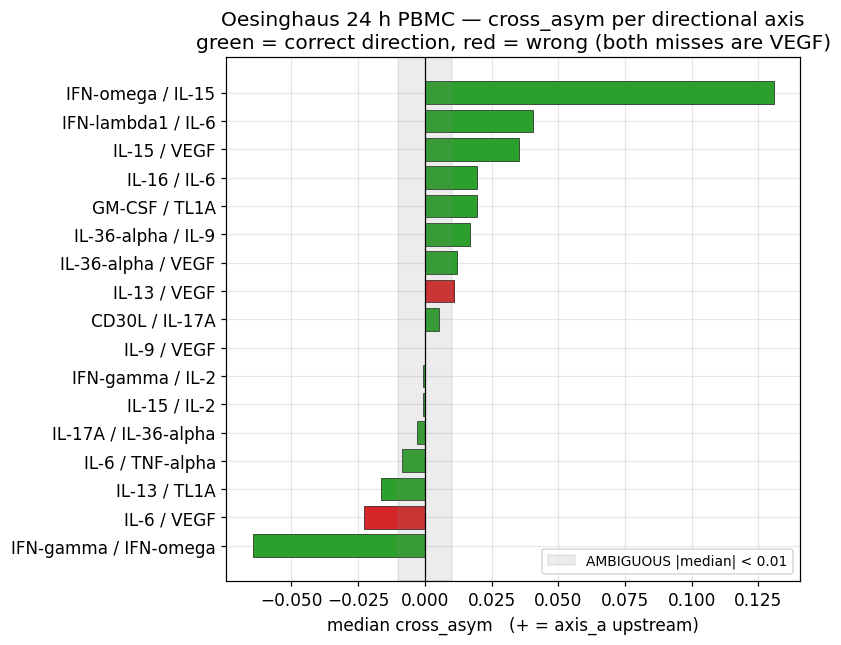

In [4]:
d = calls.copy()
d["label"] = d["condition_a"] + " / " + d["condition_b"]
d["correct"] = strict["correct"].values
d = d.sort_values("cross_asym_median").reset_index(drop=True)
colors = ["#2ca02c" if c else "#d62728" for c in d["correct"]]

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(d["label"], d["cross_asym_median"], color=colors, edgecolor="k", linewidth=0.4)
ax.axvspan(-cfg.magnitude_threshold, cfg.magnitude_threshold, color="grey", alpha=0.15,
           label=f"AMBIGUOUS |median| < {cfg.magnitude_threshold}")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("median cross_asym   (+ = axis_a upstream)")
ax.set_title("Oesinghaus 24 h PBMC — cross_asym per directional axis\n"
             "green = correct direction, red = wrong (both misses are VEGF)")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## 4. Antisymmetric cross_asym vs the symmetric control

The headline of the method: the **antisymmetric** `cross_asym` recovers direction
(~88%), while the **symmetric** `directional_score` — identical signatures, identical
data — is near chance, because its sign cannot encode direction for self-signatures.

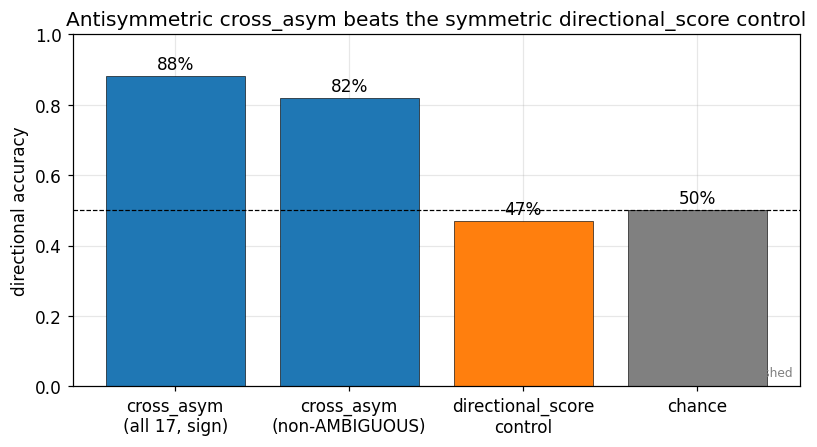

In [5]:
names = ["cross_asym\n(all 17, sign)", "cross_asym\n(non-AMBIGUOUS)",
         "directional_score\ncontrol", "chance"]
vals = [acc_all, acc_scored, dirscore_acc, 0.5]
bar_colors = ["#1f77b4", "#1f77b4", "#ff7f0e", "grey"]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(names, vals, color=bar_colors, edgecolor="k", linewidth=0.4)
ax.axhline(0.5, color="k", ls="--", lw=0.8)
ax.set_ylim(0, 1.0)
ax.set_ylabel("directional accuracy")
ax.set_title("Antisymmetric cross_asym beats the symmetric directional_score control")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.0%}", ha="center", fontsize=11)
ax.text(0.99, 0.02, f"control = {dirscore_src}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, color="grey")
fig.tight_layout()
plt.show()

## 5. Direction recovery by expected sign

`a_to_b` axes should be positive, `b_to_a` axes negative. The near-zero (AMBIGUOUS)
axes cluster around 0 — these are the calls cascadir's magnitude gate withholds.

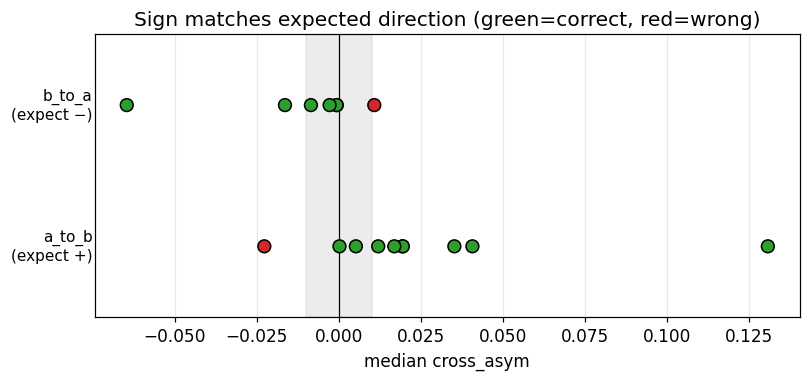

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
groups = [("a_to_b\n(expect +)", strict[strict["expected_sign"] == 1]),
          ("b_to_a\n(expect −)", strict[strict["expected_sign"] == -1])]
for ypos, (name, grp) in enumerate(groups):
    pt_colors = ["#2ca02c" if c else "#d62728" for c in grp["correct"]]
    ax.scatter(grp["cross_asym_median"], [ypos] * len(grp), c=pt_colors,
               s=70, edgecolor="k", zorder=3)
    ax.text(-0.075, ypos, name, ha="right", va="center", fontsize=10)
ax.axvline(0, color="k", lw=0.8)
ax.axvspan(-cfg.magnitude_threshold, cfg.magnitude_threshold, color="grey", alpha=0.15)
ax.set_yticks([])
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("median cross_asym")
ax.set_title("Sign matches expected direction (green=correct, red=wrong)")
fig.tight_layout()
plt.show()

## 6. Classification and the magnitude–consensus gate

cascadir grades each axis STRONG / WEAK / AMBIGUOUS from the magnitude (`|median|`) and
the sign-consensus across cell types. STRONG = `|median| ≥ 0.01` **and** consensus ≥ 0.75.

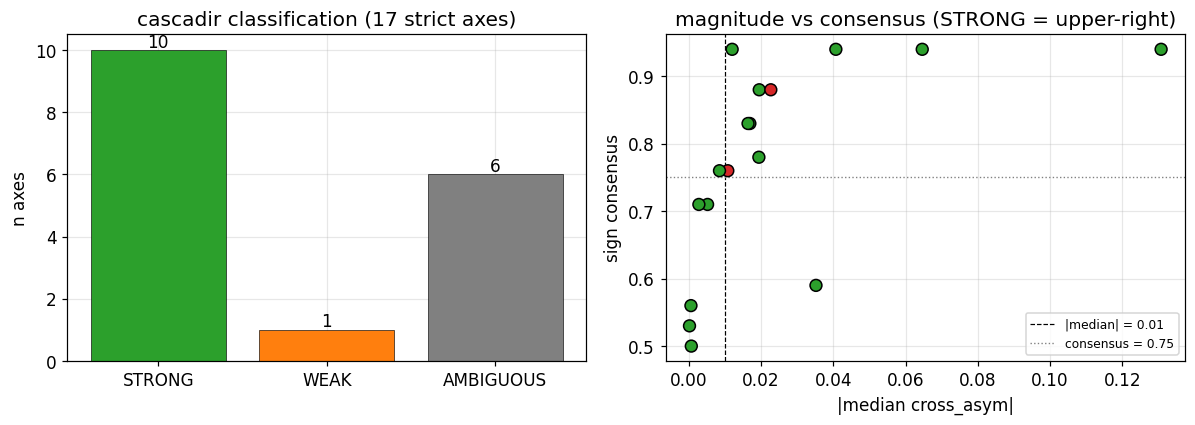

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cc = calls["classification"].value_counts().reindex(
    ["STRONG", "WEAK", "AMBIGUOUS"]).fillna(0)
axes[0].bar(cc.index, cc.values, color=["#2ca02c", "#ff7f0e", "grey"],
            edgecolor="k", linewidth=0.4)
axes[0].set_ylabel("n axes")
axes[0].set_title("cascadir classification (17 strict axes)")
for i, v in enumerate(cc.values):
    axes[0].text(i, v + 0.1, int(v), ha="center")

pt_colors = ["#2ca02c" if c else "#d62728" for c in strict["correct"]]
axes[1].scatter(strict["cross_asym_median"].abs(), strict["sign_consensus"],
                c=pt_colors, s=60, edgecolor="k", zorder=3)
axes[1].axvline(cfg.magnitude_threshold, color="k", ls="--", lw=0.8,
                label=f"|median| = {cfg.magnitude_threshold}")
axes[1].axhline(cfg.strong_consensus, color="grey", ls=":", lw=0.9,
                label=f"consensus = {cfg.strong_consensus}")
axes[1].set_xlabel("|median cross_asym|")
axes[1].set_ylabel("sign consensus")
axes[1].set_title("magnitude vs consensus (STRONG = upper-right)")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

## Bottom line

- **cross_asym recovers cascade direction on Oesinghaus at ~88%** (sign over the 17
  audited directional axes); among cascadir's non-AMBIGUOUS calls it stays well above
  chance.
- The **antisymmetric** statistic is essential: the **symmetric** `directional_score`
  control, on the *same* signatures and data, is near chance.
- The **only two misses both involve VEGF** — a known weak-signature failure mode, not a
  systematic error.
- `cross_asym` gives **direction, not existence** — Path A (`discover_axes`) decides
  *whether* a pair is coupled. This notebook scored a pre-registered set of known pairs.